In [2]:
import os
import glob
import json

import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter

import numpy as np
import torch
import matplotlib.pyplot as plt

import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import igraph as ig
import leidenalg
import networkx as nx
import graph_tool.all as gt
from graph_tool.all import Graph, minimize_blockmodel_dl
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score as ARI
from graspologic.models import SBMEstimator
from graspologic.embed.ase import AdjacencySpectralEmbed
from sklearn.mixture import GaussianMixture

In [17]:
from rpy2.robjects.packages import importr
import rpy2.robjects.packages as rpackages
from rpy2.robjects.vectors import StrVector

def install_r_dependencies():
    utils = rpackages.importr('utils')
    utils.chooseCRANmirror(ind=1) # Select the first mirror automatically
    
    # List of required R packages
    packnames = ('vblpcm', 'network', 'sna')
    
    # Select packages not yet installed
    names_to_install = [x for x in packnames if not rpackages.isinstalled(x)]
    
    if len(names_to_install) > 0:
        print(f"Installing R packages: {names_to_install}...")
        utils.install_packages(StrVector(names_to_install))
    else:
        print("All R packages already installed.")

# Run this once
install_r_dependencies()

R callback write-console: Installing package into ‘/home/coccobill/R/x86_64-pc-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)
  


Installing R packages: ['vblpcm']...


In [3]:
import graspologic

3.4.4


In [ ]:
def draw_graph_hard_clusters(A, y, class_colors=None, class_labels=None, node_size=None, results_dir: str=None, algo: str =None):
    """
    A : (n,n) 
    y : (n,k) 
    class_colors : coleurs, facultatives
    node_size : taille des nodes
    """
    n = len(y)
    k = int(np.max(y))

    if not node_size: 
        node_size = 6000/n

    if not class_colors:
        cmap = plt.get_cmap("tab10")
        class_colors = [mcolors.to_hex(cmap(i % cmap.N)) for i in range(k+1)]
    
    if class_labels is None:
        class_labels = [f"Class {i}" for i in range(k+1)]

    node_colors = [ class_colors[i] for i in y]

    if np.issubdtype(np.array(node_colors).dtype, np.number):
        cmap = plt.get_cmap("tab10")
        node_colors = [cmap(v / max(node_colors)) for v in node_colors]
    

    G = nx.from_numpy_array(A)
    pos = nx.spring_layout(G, seed=0)

    fig, ax = plt.subplots(figsize=(8,8))
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4)
    nx.draw_networkx_nodes(G, pos,
                           node_color=node_colors,
                           node_size=node_size,
                           edgecolors='black',
                           linewidths=0.5,
                           ax=ax)


    for (x, y) in pos.values():
        circ = plt.Circle((x, y), node_size/30000, fill=False, edgecolor='black', lw=0.5)
        ax.add_patch(circ)



    legend_patches = [Patch(facecolor=c, edgecolor='black', label=label) for c, label in zip(class_colors, class_labels)]
    ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.15, 1))

    
    ax.set_aspect('equal')
    ax.axis('off')


    if results_dir is not None:
        plt.savefig(os.path.join(results_dir, algo+"_hard_clusters.png"), bbox_inches='tight', dpi=300)
    
    #plt.show()
    plt.close()




In [5]:
#--------------------------------------------------------------
#Algorithmes
#-----------------------------------------------------------------


#SBM avec graph_tool, 
#SEMBRA UNA MERDA, FUNZIA

def run_graphtool_sbm(A):
    # 1. Convert Numpy Adjacency to Graph-Tool Graph
    g = gt.Graph(directed=False)
    sources, targets = A.nonzero()
    edge_list = np.column_stack((sources, targets))
    
    # Filter for undirected (keep only source <= target to avoid duplicates)
    if not g.is_directed():
        mask = edge_list[:, 0] <= edge_list[:, 1]
        edge_list = edge_list[mask]
        
    g.add_edge_list(edge_list)

    # 2. Run SBM Inference
    state = gt.minimize_blockmodel_dl(g)

    # --- FIX STARTS HERE ---
    
    # 3. Extract and Remap Block Assignments
    # z_raw contains the original labels (e.g., 0, 5, 10)
    z_raw = state.get_blocks().get_array()
    
    # np.unique with return_inverse=True does two things:
    # 'unique_labels': The sorted original labels (e.g., [0, 5, 10])
    # 'z': The remapped labels 0..K-1 (e.g., [0, 1, 2]) matching the original structure
    unique_labels, z = np.unique(z_raw, return_inverse=True)
    K = len(unique_labels)
    
    # Calculate size of each block (n_r) using the remapped z
    # Since z is now 0..K-1, counts corresponds exactly to indices 0..K-1
    _, n_r = np.unique(z, return_counts=True)
    
    # 4. Compute Connectivity Matrix (B)
    # The state matrix uses the ORIGINAL labels as indices.
    # It might be a large sparse matrix if labels are high numbers (e.g. 10).
    m_counts = state.get_matrix()
    E_full = np.array(m_counts.todense())
    
    # We extract only the sub-matrix corresponding to our existing blocks.
    # np.ix_ allows us to grab rows [0, 5, 10] and columns [0, 5, 10]
    E_rs = E_full[np.ix_(unique_labels, unique_labels)]
    
    # Initialize Probability Matrix B
    B = np.zeros((K, K))
    
    for r in range(K):
        for s in range(K):
            if r == s:
                # Possible edges inside a block (Undirected)
                possible = n_r[r] * (n_r[r] - 1)
            else:
                # Possible edges between blocks
                possible = n_r[r] * n_r[s]
            
            if possible > 0:
                B[r, s] = E_rs[r, s] / possible
            else:
                B[r, s] = 0.0

    # Ensure numerical symmetry (floating point errors can sometimes occur)
    B = (B + B.T) / 2

    return {"z": z, "K": K, "B": B}



#SBM avec R NON FUNZIONA


#Spectral clustering avec sklearn #FUNZIONA


def run_spectral_clustering(A, K=3):
    sc = SpectralClustering(
        n_clusters=K,
        affinity='precomputed',
        assign_labels='kmeans'
    )
    z = sc.fit_predict(A)
    return {"z": z, "K": K, "B": None}





#louvain


def run_louvain(A):
    G = nx.from_numpy_array(A)
    
    # Use native networkx implementation
    # seed is optional, but good for reproducibility
    communities = nx.community.louvain_communities(G, seed=123)
    
    # Convert list of sets to assignment array z
    z = np.zeros(len(A), dtype=int)
    for cluster_id, nodes in enumerate(communities):
        for node in nodes:
            z[node] = cluster_id
            
    K = len(communities)
    
    # Bonus: Compute B (block density) so it's not None
    # We can reuse a simplified version of the logic we used before
    B = np.zeros((K, K))
    
    # Simple calculation of B for Louvain (empirical probability)
    # Warning: This can be slow for massive graphs. 
    # If speed is key, stick to B=None.
    for r in range(K):
        for s in range(K):
            nodes_r = list(communities[r])
            nodes_s = list(communities[s])
            
            # Count actual edges between block r and s
            subgraph = nx.subgraph(G, nodes_r + nodes_s)
            m_rs = 0
            
            # This loop is naive; matrix operations would be faster but this is readable
            if r == s:
                m_rs = nx.subgraph(G, nodes_r).number_of_edges()
                possible = len(nodes_r) * (len(nodes_r) - 1) / 2
            else:
                # Count edges strictly between the two sets
                # (NetworkX doesn't have a fast built-in for "edges between set A and B")
                # We approximate or skip for speed, or calculate precisely:
                # Precise:
                edges = nx.edge_boundary(G, nodes_r, nodes_s)
                m_rs = len(list(edges))
                possible = len(nodes_r) * len(nodes_s)
            
            if possible > 0:
                B[r, s] = m_rs / possible

    return {"z": z, "K": K, "B": B}



#leiden

def run_leiden(A):
    g = ig.Graph.Adjacency(A.tolist(), mode="undirected")
    partition = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition)
    z = np.array(partition.membership)
    K = len(np.unique(z))
    return {"z": z, "K": K, "B": None}

#Fake   VBLPCM avec Python


def run_vblpcm_python(A, max_k=10):
    # 1. Embed the graph into Latent Space
    # Adjacency Spectral Embed (ASE) finds the latent positions (X)
    # n_components=None means it will automatically select the best dimensions
    # using the Zhu-Godsell elbow method.
    ase = AdjacencySpectralEmbed(n_components=None) 
    X = ase.fit_transform(A)
    
    # If the graph is directed, ASE returns a tuple (X_out, X_in).
    # We concatenate them to get a full feature vector for clustering.
    if isinstance(X, tuple):
        X = np.concatenate(X, axis=1)

    # 2. Cluster the Latent Positions using Gaussian Mixture Models
    # This replicates the "Latent Position Cluster Model" logic
    best_gmm = None
    lowest_bic = np.inf 
    
    for k in range(1, max_k + 1):
        try:
            # Fit GMM
            gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
            gmm.fit(X)
            
            # Calculate BIC (Lower is better in sklearn)
            bic = gmm.bic(X)
            
            if bic < lowest_bic:
                lowest_bic = bic
                best_gmm = gmm
        except ValueError:
            continue
            
    if best_gmm is None:
        # Fallback if BIC fails (rare)
        best_gmm = GaussianMixture(n_components=1).fit(X)
        
    # 3. Extract Assignments
    z = best_gmm.predict(X)
    K = best_gmm.n_components
    
    # 4. Compute Connectivity Matrix (B) empirically
    # We estimate the edge density between the found clusters.
    B = np.zeros((K, K))
    
    for r in range(K):
        for s in range(K):
            nodes_r = np.where(z == r)[0]
            nodes_s = np.where(z == s)[0]
            
            if len(nodes_r) == 0 or len(nodes_s) == 0:
                continue
                
            # Extract edges between group r and group s
            submatrix = A[np.ix_(nodes_r, nodes_s)]
            edges_count = np.sum(submatrix)
            
            if r == s:
                # Undirected internal edges
                # A contains symmetric entries, so sum is 2 * edges.
                # Max ordered pairs is n * (n-1).
                possible = len(nodes_r) * (len(nodes_r) - 1)
            else:
                # Between groups
                possible = len(nodes_r) * len(nodes_s)
                
            if possible > 0:
                B[r, s] = edges_count / possible
            else:
                B[r, s] = 0.0

    # Symmetrize B (if undirected)
    B = (B + B.T) / 2

    return {"z": z, "K": K, "B": B}



In [6]:


#VBLPCM avec R


def run_vblpcm_r(A, max_k=5):
    """
    Runs the VBLPCM algorithm via R.
    
    Parameters:
    - A: Numpy adjacency matrix
    - max_k: Maximum number of clusters to test. 
             Warning: VBLPCM is slow. Keep this low (e.g., 5-10) for testing.
    """
    
    # Determine if directed or undirected
    is_directed = not np.allclose(A, A.T)
    r_directed = "TRUE" if is_directed else "FALSE"

    with localconverter(default_converter + numpy2ri.converter):
        ro.globalenv["A"] = A
        ro.globalenv["max_k"] = max_k
        ro.globalenv["is_dir"] = is_directed # Boolean for R
        
        ro.r("library(vblpcm)")
        ro.r("library(network)")

        # We define an R script to loop through K=1 to max_k
        # finding the one with the best BIC.
        ro.r(f"""
             # 1. Convert matrix to network object (required by vblpcm)
             net <- network(as.matrix(A), directed = {r_directed})
             
             best_bic <- -Inf
             best_fit <- NULL
             
             # 2. Loop to find optimal number of groups (G)
             for (g in 1:max_k) {{
                 # Wrap in tryCatch because vblpcm sometimes fails to converge for specific G
                 tryCatch({{
                     # Initialize
                     # plotting=FALSE is crucial to prevent hanging
                     v_start <- vblpcmstart(net, G=g, plot=FALSE, verbosity=0)
                     
                     # Fit
                     v_fit <- vblpcmfit(v_start, STEPS=50, plotting=FALSE)
                     
                     # Check BIC (vblpcm aims to maximize this value)
                     if (!is.nan(v_fit$BIC) && v_fit$BIC > best_bic) {{
                         best_bic <- v_fit$BIC
                         best_fit <- v_fit
                     }}
                 }}, error=function(e){{}}) # Skip if error
             }}
             
             if (is.null(best_fit)) {{
                 stop("VBLPCM failed to converge for any K.")
             }}
             
             # 3. Extract Best Group Assignments
             # vblpcm stores probabilities of node i being in group g in fit$Y
             # We take the argmax to get hard assignments
             Y_probs <- best_fit$Y
             z_r <- apply(Y_probs, 1, which.max)
             
             """)
        
        # Extract z (convert from R 1-based indexing to Python 0-based)
        z_raw = np.array(ro.r("z_r"))
        z = z_raw - 1
        
        K = len(np.unique(z))

        # 4. Compute Connectivity Matrix (B) empirically
        # VBLPCM is a latent space model, not a block model, so it doesn't 
        # have an explicit "B" matrix parameter. We estimate it from the data.
        B = np.zeros((K, K))
        
        for r in range(K):
            for s in range(K):
                nodes_r = np.where(z == r)[0]
                nodes_s = np.where(z == s)[0]
                
                if len(nodes_r) == 0 or len(nodes_s) == 0:
                    continue

                # Extract submatrix and count edges
                submatrix = A[np.ix_(nodes_r, nodes_s)]
                edges_count = np.sum(submatrix)
                
                if r == s:
                    # Undirected internal: n(n-1) possible directed pairs
                    # (Assuming A is symmetric with 0 diagonal)
                    if is_directed:
                        possible = len(nodes_r) * (len(nodes_r) - 1)
                    else:
                        # For undirected, A has counts both ways, so we divide by n(n-1)
                        # effectively treating it as directed pairs.
                        possible = len(nodes_r) * (len(nodes_r) - 1)
                else:
                    possible = len(nodes_r) * len(nodes_s)
                    
                if possible > 0:
                    B[r, s] = edges_count / possible
                else:
                    B[r, s] = 0.0

    return {"z": z, "K": K, "B": B}

In [7]:
def list_npy_graphs(data_dir: str):
    """
    Retourne les chemins des fichiers .npy dont le nom commence par 'A'.
    """
    return sorted(glob.glob(os.path.join(data_dir, "A*.npy")))



def load_A(path: str, as_bool: bool = True, validate: bool = True) -> np.array:
    """
    Charge une matrice A (carrée, symétrique, diag=0 si validate).
    as_bool: binarise A (uint8) si True.
    """
    A = np.load(path)
    if validate:
        assert A.ndim == 2 and A.shape[0] == A.shape[1], "A doit être carrée."
        if np.issubdtype(A.dtype, np.floating):
            assert np.allclose(A, A.T, atol=1e-8), "A doit être symétrique."
        else:
            assert (A == A.T).all(), "A doit être symétrique."
        assert np.allclose(np.diag(A), 0), "diag(A) doit être nulle."
    if as_bool:
        A = (A != 0).astype(np.uint8)
    return A

In [ ]:
def compute_H(eta, eta_prime, N):


    U = eta @ eta.T
    U_prime = eta_prime @ eta_prime.T
    K = eta.shape[0]

    mask = [[bool(i<=j) for i in range(K)] for j in range(K)]

    l1_difference = np.sum(np.abs(U-U_prime)[mask])

    return np.sqrt(2*l1_difference/(N*(N-1)))


def evaluate_algorithm(A: np.array, result: dict, z_true=None, eta_true = None): 
    """
    result = {"z": cluster_labels, "K": int number of clusters, "eta": connectivity or None}

    Returns a dict of metrics ARI, eta_est, eta_error_fro (if true eta given).
    """

    z = result["z"]
    K = result["K"]
    eta = result["B"]

    metrics = {}

    # 1) ARI (if true labels available)
    if z_true is not None:
        metrics["ARI"] = ARI(z_true, z)

    # 2) Connectivity matrix: use algorithm estimate or compute ours
    if eta is None:
        eta_est = np.zeros((K, K)) #estimate_connectivity(A, z, K) --- IGNORE ---
    else:
        eta_est = eta

    metrics["eta_est"] = eta_est

    # 3) Connectivity matrix error (if ground truth exists)
    if eta_true is not None:
        metrics["H"] = compute_H(eta_est, eta_true, z.shape[0])


    metrics["K_est"] = K
    metrics["z"] = z

    return metrics

In [15]:
def run_experiment(A: np.array, z_true: list =None, B_true: np.array =None, algorithms: dict=None):
    """
    algorithms is a dict: 
        {"name": function(A) -> result_dict}

    Returns a dictionary with the results of evaluate_algorithm
    """
    results = {}

    for name, algo in algorithms.items():
        result = algo(A)
        metrics = evaluate_algorithm(A, result, z_true, B_true)
        results[name] = metrics

    return results



algos = {
    "SBM_Python": run_graphtool_sbm,
    "Spectral_Clustering": run_spectral_clustering,
    "Louvain": run_louvain,
    "Leiden": run_leiden,
    "fake_VBLPCM_python": run_vblpcm_python, 
    "vblpcm_r": run_vblpcm_r
}


In [10]:
#-------------------------------------
# CONFIG
#-------------------------------------
DATA_DIR =  "data_synthetic/assortative" #"miscdata" 

ALL = False             # Évaluer tous les sujets dans DATA_DIR
SUBJECT_IDX = 0          # Sujet à évaluer DANS DATA_DIR
K = 3                    # Nombre de clusters (si applicable)
results_dir = "Comparison"

In [ ]:
from deep_lpbm_copy import main as run_deepLPBM




def main():
    # --- Chargement des fichiers ---
    files = list_npy_graphs(DATA_DIR)
    assert len(files) > 0, f"Aucun fichier .npy trouvé dans {DATA_DIR}"
    print(f"{len(files)} matrices détectées dans {DATA_DIR}")


    # --- 2. Sélection du sujet ---
    if not ALL:
        files = [files[SUBJECT_IDX]]

    for file_idx, A_path in enumerate(files):
        print(f"\n=== Sujet {file_idx + 1}/{len(files)} : {A_path} ===")

         # Charger la matrice A
        A = load_A(A_path)
        subject_name = os.path.splitext(os.path.basename(A_path))[0].replace("A_", "")


        y_true = None
        eta_true = None 

        y_path = os.path.join(DATA_DIR, os.path.basename(A_path).replace("A_", "y_"))
        if os.path.exists(y_path):
            print("\n=== Données synthétiques détectées ===")
            y_true = np.load(y_path).astype(int).ravel()
            K_true = np.unique(y_true).size


        eta_path = os.path.join(DATA_DIR, os.path.basename(A_path).replace("A_", "eta_"))
        if os.path.exists(eta_path):
            print("\n=== Données synthétiques détectées ===")
            eta_true = np.load(eta_path).astype(int).ravel()


        if results_dir is not None:
            os.makedirs(results_dir, exist_ok=True)
            ari_path = os.path.join(results_dir, "ARI.txt")
            partial_memb_eval_path = os.path.join(results_dir, "partial_memebership_evaluation.txt")
            img_path = os.path.join(results_dir, "images")

            with open(ari_path, 'w') as fp:
                pass
            with open(partial_memb_eval_path, 'w') as fp:
                pass
   
            #os.makedirs(ari_path, exist_ok=True)
            #os.makedirs(partial_memb_eval_path, exist_ok=True)
            os.makedirs(img_path, exist_ok=True)

        results = run_experiment(A, y_true, eta_true, algorithms=algos)


        deeplpbm_res = run_deepLPBM( DATA_DIR = DATA_DIR, SUBJECT_IDX = SUBJECT_IDX, comparison=True, Q_true=K_true)
        results['deepLPBM'] = evaluate_algorithm(A, deeplpbm_res, y_true, eta_true)

        

        ARI = {}
        PME = {}
        for algo in results.keys():
            ARI[algo] = results[algo].get("ARI", None)
            PME[algo] = results[algo].get("H", None)
            
        with open(ari_path, 'w') as f:
            for algo, score in ARI.items():
                f.write(f"{algo},{score}\n")

        with open(partial_memb_eval_path, 'w') as f:
            for algo, score in PME.items():
                f.write(f"{algo},{score}\n")

        for algo in results.keys():
            draw_graph_hard_clusters(A, results[algo]["z"], results_dir=img_path, algo=algo)
    return ARI, PME

In [16]:
main()

R callback write-console: Error in library(vblpcm) : there is no package called ‘vblpcm’
  


10 matrices détectées dans data_synthetic/assortative

=== Sujet 1/1 : data_synthetic/assortative/A_000.npy ===

=== Données synthétiques détectées ===

=== Données synthétiques détectées ===
eta (4, 4)
u (4, 4)
eta (3, 3)
u (3, 3)
eta (5, 5)
u (5, 5)
eta (5, 5)
u (5, 5)
eta (9, 9)
u (9, 9)


RRuntimeError: Error in library(vblpcm) : there is no package called ‘vblpcm’


10 matrices détectées dans data_synthetic/assortative

=== Sujet 1/1 : data_synthetic/assortative/A_000.npy ===

=== Données synthétiques détectées ===

=== Données synthétiques détectées ===
eta (1, 1)
u (1, 1)
eta (3, 3)
u (3, 3)
eta (5, 5)
u (5, 5)
eta (6, 6)
u (6, 6)
eta (1, 1)
u (1, 1)
cazzo
Sujet sélectionné : 000 dans le dossier data_synthetic/assortative

=== Entraînement pour Q = 5 ===
[Deep LPBM + GCNConv] Q=5 — ELBO finale : -598.2364

=== Meilleur modèle ===
Q optimal (AIC) : 5
AIC : -825.12   |   BIC : -1412.85   |   ICL : -648.45
η shape : (50, 5)   |   Π shape : (5, 5)

=== Données synthétiques détectées ===
K vrai : 5   |   Q trouvé : 5
=== Évaluation du modèle ===

=== Comparaison Π ===
Différence moyenne |Π_true - Π_pred| = 0.1742
Shape Π_true = (5, 5) | Shape Π_pred = (5, 5)

Score H (appartenances partielles) = 1.4727
(4, 4)
ytrue: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
yaligned [0 0 1 2 0 0 0 1 0 2 2 1

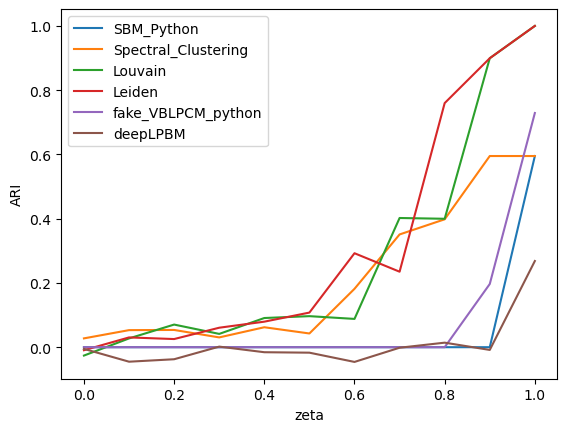

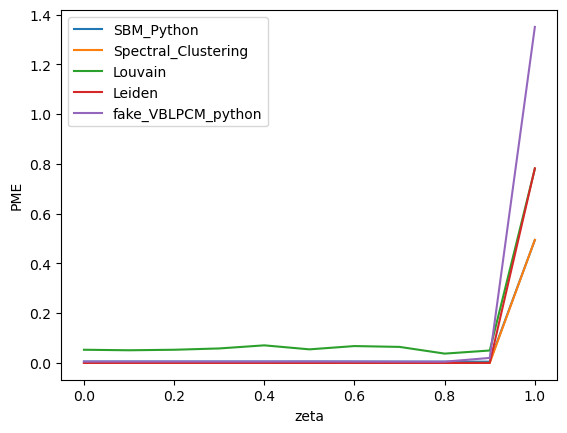

In [13]:
#ESTIMATION dependent on zeta

from synthetic_data import generate_synthetic

zetas = np.array([j/10 for j in range(6, 11)])

total_ARI = {}
total_PME = {}

for algo in algos: 
    total_ARI[algo] = []
    total_PME[algo] = []

total_ARI['deepLPBM'] = []
total_PME['deepLPBM'] = []


for x in range(11):
    generate_synthetic(mode="assortative", #disassortative, hub, disassortative
                       outdir="data_synthetic",
                       n_graphs=1,
                       N=50,
                       Q=5,
                       beta=0.7,
                       eps=0.05,
                       zeta=zetas[x], # 1 for hard clustering and in (0,1) for partial
                       seed=0)
    
    partial_ARI, partial_PME = main()

    for algo in partial_ARI.keys():
        total_ARI[algo].append(partial_ARI[algo])
        total_PME[algo].append(partial_PME[algo])


#ARI 
plt.plot()
plt.xlabel("zeta")
plt.ylabel("ARI")
for algo in total_ARI.keys(): 
    plt.plot(zetas, total_ARI[algo], label=algo)

plt.legend()
plt.show()
plt.close() 



#PARTIAL MEMBERSHIP EVALUATION
plt.plot()
plt.xlabel("zeta")
plt.ylabel("PME")
for algo in algos: 
    plt.plot(zetas, total_PME[algo], label=algo)

plt.legend()
plt.show()
plt.close()


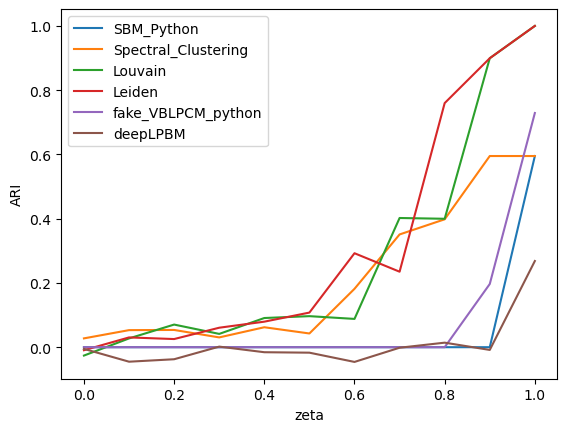

In [14]:
#ARI 
plt.plot()
plt.xlabel("zeta")
plt.ylabel("ARI")
for algo in total_ARI.keys(): 
    plt.plot(zetas, total_ARI[algo], label=algo)

plt.legend()
plt.show()
plt.close()

Generating Synthetic Graph...
Loading Data...
Loaded Graph with 60 nodes.
Probability Matrix (Pi):
 [[0.05 0.9  0.9  0.9  0.9 ]
 [0.9  0.05 0.9  0.9  0.9 ]
 [0.9  0.9  0.05 0.9  0.9 ]
 [0.9  0.9  0.9  0.05 0.9 ]
 [0.9  0.9  0.9  0.9  0.05]]
Cluster Labels: [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 3
 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4]
Visualizing...


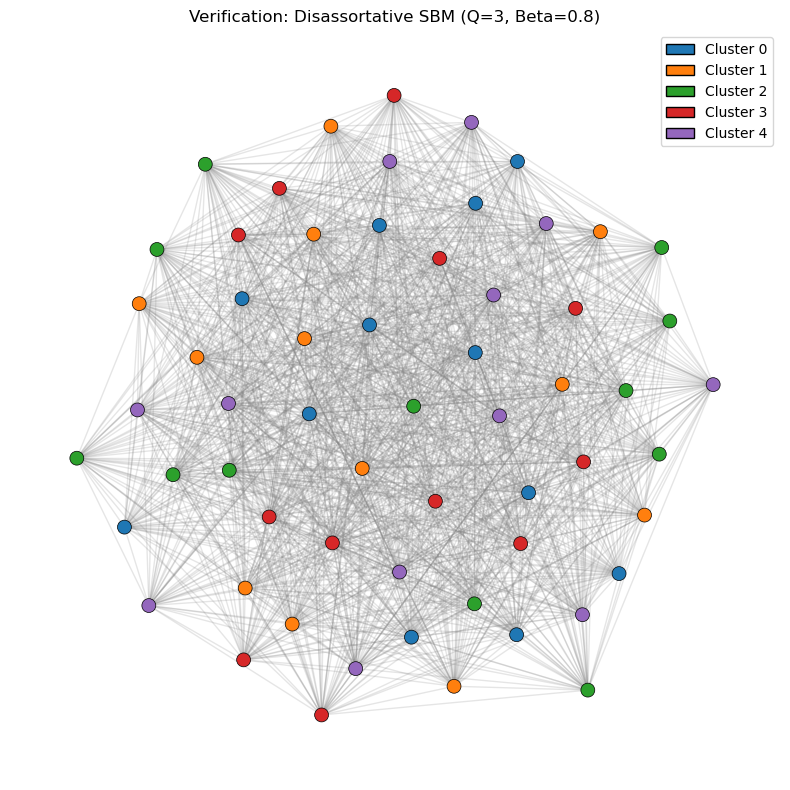

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import networkx as nx

# Import your generation function
# Assumes synthetic_data.py is in the same folder
try:
    from synthetic_data import generate_synthetic
except ImportError:
    print("Error: synthetic_data.py not found in the current directory.")
    exit()

# --- 1. Define the Drawing Function (Copied & Cleaned from your notebook) ---
def draw_graph_hard_clusters(A, y, class_colors=None, class_labels=None, node_size=None, title=""):
    """
    Draws the graph using a spring layout to visualize clusters.
    """
    n = len(y)
    k = int(np.max(y)) + 1

    if not node_size: 
        node_size = 6000/n

    # Set up colors
    if not class_colors:
        cmap = plt.get_cmap("tab10")
        class_colors = [mcolors.to_hex(cmap(i % cmap.N)) for i in range(k)]
    
    if class_labels is None:
        class_labels = [f"Cluster {i}" for i in range(k)]

    # Map labels to colors
    node_colors = [class_colors[int(i)] for i in y]

    # Build NetworkX graph
    G = nx.from_numpy_array(A)
    
    # Spring layout treats edges like springs -> connected nodes bunch together
    pos = nx.spring_layout(G, seed=42, k=1/np.sqrt(n)*2) 

    fig, ax = plt.subplots(figsize=(8,8))
    
    # Draw Edges
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, edge_color='gray')
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos,
                           node_color=node_colors,
                           node_size=node_size,
                           edgecolors='black',
                           linewidths=0.5,
                           ax=ax)

    # Legend
    legend_patches = [Patch(facecolor=c, edgecolor='black', label=label) 
                      for c, label in zip(class_colors, class_labels)]
    ax.legend(handles=legend_patches, loc='upper right')
    
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# --- 2. Generate Data for Verification ---
print("Generating Synthetic Graph...")

# Parameters chosen to make visual verification EASY:
# - Assortative: Nodes should clump with their own color.
# - Zeta=1.0: Hard clustering (no fuzziness).
# - Beta=0.8, Eps=0.05: High signal-to-noise ratio.
out_dir = "debug_data"
mode = "disassortative"

output_path = generate_synthetic(
    outdir=out_dir,
    mode=mode,
    n_graphs=1,
    N=60,       # Small enough to see clearly
    Q=5,        # 3 Clusters
    beta=0.9,   # Strong internal connections
    eps=0.05,   # Weak external connections
    zeta=1.0,   # Pure communities (no mixed membership)
    seed=999    # Random seed
)

# --- 3. Load the Data ---
print("Loading Data...")
try:
    # synthetic_data.py uses strictly 3 digits for formatting: {:03d}
    A = np.load(f"{out_dir}/{mode}/A_000.npy")
    y_true = np.load(f"{out_dir}/{mode}/y_000.npy")
    Pi = np.load(f"{out_dir}/{mode}/Pi_000.npy")
    
    print(f"Loaded Graph with {A.shape[0]} nodes.")
    print("Probability Matrix (Pi):\n", Pi)
    print("Cluster Labels:", y_true)

    # --- 4. Visualize ---
    print("Visualizing...")
    draw_graph_hard_clusters(
        A, 
        y_true, 
        title=f"Verification: {mode.capitalize()} SBM (Q=3, Beta=0.8)"
    )
    
except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print(f"Check directory: {out_dir}/{mode}")